<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_10_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 10: Image data comparison using autoencoder neural network on CIFAR-10 dataset

This notebook demonstrates how to build a Convolutional Autoencoder to compress and reconstruct images from the CIFAR-10 dataset. We will compare the original input images with the model's reconstructed outputs.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Loading and Preprocessing
We load the CIFAR-10 dataset. Since autoencoders are unsupervised models (they learn to reconstruct the input, not predict a label), we don't need the `y_train` or `y_test` labels. We just normalize the pixel values to be between 0 and 1.

In [ ]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0.0 and 1.0
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f'Training images shape: {x_train.shape}')
print(f'Testing images shape: {x_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)


### 2. Building the Convolutional Autoencoder
The network has two main parts:
1. **Encoder:** Uses `Conv2D` and `MaxPooling2D` layers to compress the 32x32x3 image into a smaller bottleneck representation.
2. **Decoder:** Uses `Conv2D` and `UpSampling2D` layers to decompress the bottleneck back into a 32x32x3 image. The final layer uses a `sigmoid` activation to ensure output pixels remain between 0 and 1.

In [ ]:
autoencoder = models.Sequential([
    # ENCODER
    layers.InputLayer(input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'), # Compresses to 16x16
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'), # Compresses to 8x8 (Bottleneck)

    # DECODER
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),                 # Decompresses to 16x16
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),                 # Decompresses to 32x32
    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same') # 3 channels for RGB
])

autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compiling and Training
We use the Adam optimizer and Mean Squared Error (MSE) loss. Notice that in `model.fit()`, we pass `x_train` as *both* the input and the target output, because the goal is to make the output match the input.

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
# We use a smaller number of epochs (10) for faster demonstration,
# but for better quality reconstructions, you can increase this to 30 or 50.
history = autoencoder.fit(x_train, x_train,
                          epochs=10,
                          batch_size=128,
                          validation_data=(x_test, x_test),
                          verbose=1)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 357ms/step - loss: 0.0134 - val_loss: 0.0074
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 346ms/step - loss: 0.0066 - val_loss: 0.0060
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 340ms/step - loss: 0.0058 - val_loss: 0.0055
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 130s 333ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 330ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - loss: 0.0048 - val_loss: 0.0047
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 334ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 132s 337ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 131s 334ms/step - loss: 0.0044 - val_loss: 0.0043
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 137s 322ms/step - loss: 0.0043 - val_loss: 0.0042


### 4. Image Data Comparison (Original vs. Reconstructed)
We pass the test images through the trained autoencoder to get the reconstructed versions, and then plot them side-by-side to visually compare the results.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


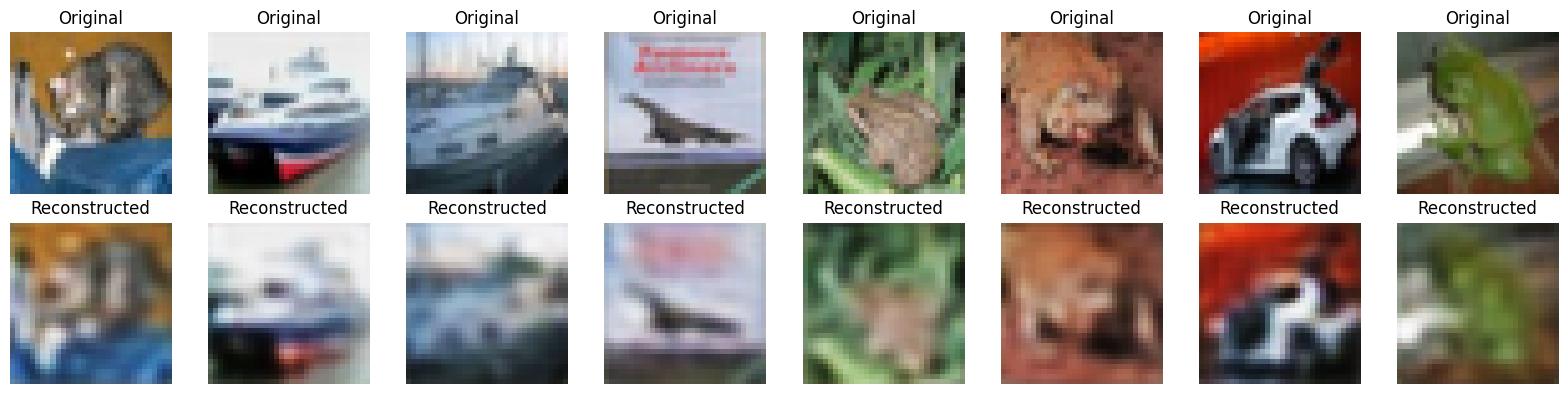

In [ ]:
# Get reconstructions for the test set
reconstructed_images = autoencoder.predict(x_test)

# Define how many images to display
n = 8
plt.figure(figsize=(16, 4))

for i in range(n):
    # Display original images (Top row)
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    # Display reconstructed images (Bottom row)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()